# Students dataset quality checks

This notebook inspects the **student-facing dataset** only.

**Input:** CSV with columns:
`revenue, costs, audited, market_focus, ceo_tenure_years, risk`

It produces:
- basic schema and missingness
- numeric summary stats
- class distribution
- categorical value distributions
- correlations
- outlier diagnostics
- key plots

Set `CSV_PATH` and run all cells.

In [1]:

# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (7.5, 5.0)
plt.rcParams["axes.grid"] = True


In [2]:

# Load dataset
CSV_PATH = "../risk_train_dataset.csv"  # <-- set your file here

df = pd.read_csv(CSV_PATH)
df.head()


,revenue,costs,audited,market_focus,ceo_tenure_years,risk
0,1.007664e+07,8.462399e+06,1.0,['Industrial'],12.734655,healthy
1,7.786446e+06,7.701863e+06,1.0,"['Ads', 'Industrial']",7.875798,cost_risk
2,1.685946e+07,1.455583e+07,1.0,"['Ads', 'Scale']",3.882066,healthy
3,9.868911e+06,7.460504e+06,1.0,['Scale'],1.570454,healthy
4,5.200840e+06,4.969181e+06,1.0,['Contract'],8.292522,cost_risk


In [3]:

# Column check + dtypes
expected = ["revenue","costs","audited","market_focus","ceo_tenure_years","risk"]
missing = [c for c in expected if c not in df.columns]
extra = [c for c in df.columns if c not in expected]

print("Missing expected columns:", missing)
print("Extra columns:", extra)

df.dtypes


Missing expected columns: []
Extra columns: []


revenue             float64
costs               float64
audited             float64
market_focus         object
ceo_tenure_years    float64
risk                 object
dtype: object

In [4]:

# Missingness report
miss = df.isna().mean().sort_values(ascending=False).to_frame("missing_rate")
miss["missing_count"] = df.isna().sum()
miss


,missing_rate,missing_count
ceo_tenure_years,0.0002,1
audited,0.0002,1
costs,0.0000,0
revenue,0.0000,0
market_focus,0.0000,0
risk,0.0000,0


Counts:
risk
healthy       2816
cost_risk     1184
sales_risk     684
both_risks     316

Proportions:
risk
healthy       0.5632
cost_risk     0.2368
sales_risk    0.1368
both_risks    0.0632


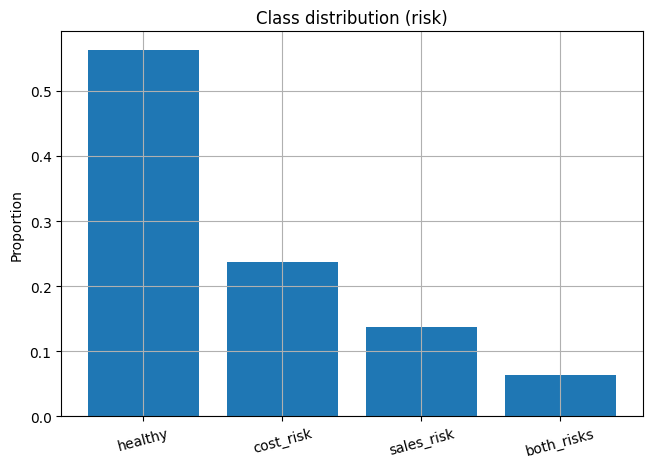

In [5]:

# Basic class distribution
dist = df["risk"].value_counts(dropna=False)
dist_norm = df["risk"].value_counts(dropna=False, normalize=True)

print("Counts:")
print(dist.to_string())
print("\nProportions:")
print(dist_norm.to_string())

plt.figure()
plt.bar(dist_norm.index.astype(str), dist_norm.values)
plt.title("Class distribution (risk)")
plt.ylabel("Proportion")
plt.xticks(rotation=15)
plt.show()


In [6]:

# Convert numeric columns safely
num_cols = ["revenue","costs","audited","ceo_tenure_years"]
num = df[num_cols].apply(pd.to_numeric, errors="coerce")

# Derived helpers (useful for diagnostics)
num["log_revenue"] = np.log(num["revenue"].clip(lower=1.0))
num["log_costs"] = np.log(num["costs"].clip(lower=1.0))
num["profit_margin_proxy"] = (num["revenue"] - num["costs"]) / num["revenue"].clip(lower=1e-12)

num.head()


,revenue,costs,audited,ceo_tenure_years,log_revenue,log_costs,profit_margin_proxy
0,1.007664e+07,8.462399e+06,1.0,12.734655,16.125730,15.951143,0.160196
1,7.786446e+06,7.701863e+06,1.0,7.875798,15.867895,15.856973,0.010863
2,1.685946e+07,1.455583e+07,1.0,3.882066,16.640423,16.493502,0.136637
3,9.868911e+06,7.460504e+06,1.0,1.570454,16.104900,15.825134,0.244040
4,5.200840e+06,4.969181e+06,1.0,8.292522,15.464331,15.418766,0.044543


In [7]:

# Numeric summary statistics
desc = num.describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]).T
desc


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
revenue,5000.0,1.479238e+07,2.227916e+07,1.799759e+05,936324.464660,1.755144e+06,4.482932e+06,8.656244e+06,1.754065e+07,4.656497e+07,9.117842e+07,8.895447e+08
costs,5000.0,1.274273e+07,2.369128e+07,-1.106274e+07,727162.320621,1.466319e+06,3.755969e+06,7.365774e+06,1.496453e+07,4.010499e+07,8.189606e+07,1.126838e+09
audited,4999.0,5.595119e-01,4.964954e-01,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
ceo_tenure_years,4999.0,6.000986e+00,4.389375e+00,3.974935e-02,0.422735,1.109562e+00,2.885087e+00,5.041003e+00,7.965004e+00,1.411026e+01,2.047731e+01,8.357357e+01
log_revenue,5000.0,1.599882e+01,1.000800e+00,1.210058e+01,13.749716,1.437806e+01,1.531579e+01,1.597379e+01,1.668003e+01,1.765636e+01,1.832833e+01,2.060622e+01
log_costs,5000.0,1.582727e+01,1.034758e+00,0.000000e+00,13.496904,1.419827e+01,1.513886e+01,1.581235e+01,1.652119e+01,1.750701e+01,1.822096e+01,2.084268e+01
profit_margin_proxy,5000.0,1.268064e-01,9.002474e-01,-4.446758e+01,-0.073584,-2.855092e-02,6.500124e-02,1.474895e-01,2.302767e-01,3.222247e-01,3.667513e-01,1.928560e+00


P(costs > revenue) = 0.089
P(costs < 0)       = 0.000
P(revenue < 0)     = 0.000


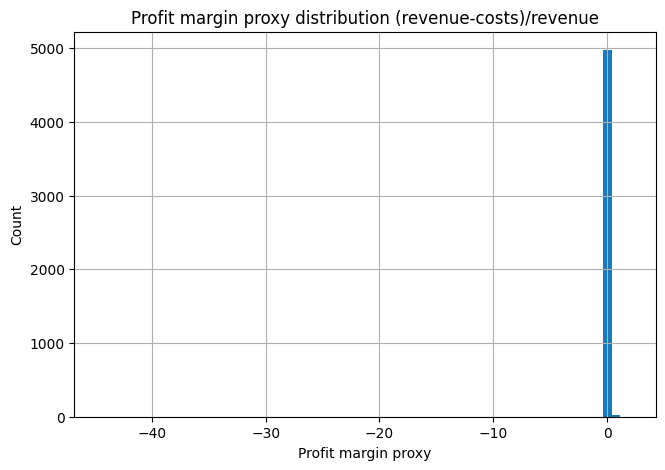

In [8]:

# Check costs>revenue (loss-making) and negative/invalid values
revenue = num["revenue"]
costs = num["costs"]

loss_rate = float((costs > revenue).mean())
neg_cost_rate = float((costs < 0).mean())
neg_rev_rate = float((revenue < 0).mean())

print(f"P(costs > revenue) = {loss_rate:.3f}")
print(f"P(costs < 0)       = {neg_cost_rate:.3f}")
print(f"P(revenue < 0)     = {neg_rev_rate:.3f}")

plt.figure()
plt.hist(num["profit_margin_proxy"].dropna(), bins=60)
plt.title("Profit margin proxy distribution (revenue-costs)/revenue")
plt.xlabel("Profit margin proxy")
plt.ylabel("Count")
plt.show()


Valid audited rate   : 1.000
Invalid audited rate : 0.000
NaN audited rate     : 0.000

Audited value counts (top):
audited
1.0    2797
0.0    2202
NaN       1


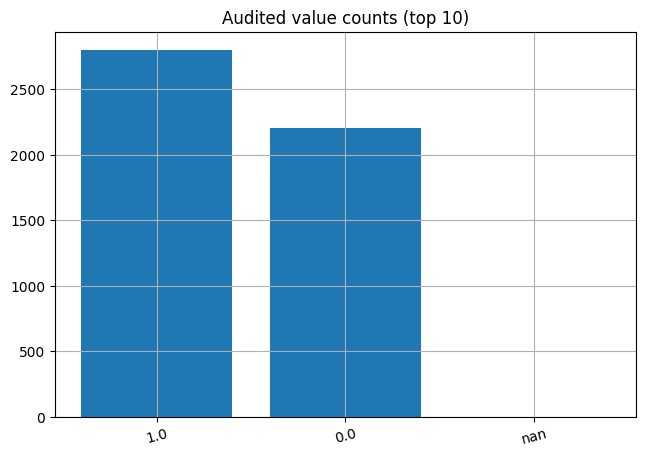

In [9]:

# Audited values: valid/invalid rates
aud = pd.to_numeric(df["audited"], errors="coerce")
valid = aud.isin([0,1])
invalid = (~valid) & (~aud.isna())

print(f"Valid audited rate   : {float(valid.mean()):.3f}")
print(f"Invalid audited rate : {float(invalid.mean()):.3f}")
print(f"NaN audited rate     : {float(aud.isna().mean()):.3f}")

print("\nAudited value counts (top):")
print(aud.value_counts(dropna=False).head(10).to_string())

plt.figure()
plt.bar(aud.value_counts(dropna=False).index.astype(str)[:10],
        aud.value_counts(dropna=False).values[:10])
plt.title("Audited value counts (top 10)")
plt.xticks(rotation=15)
plt.show()


In [10]:

# Market focus parsing helpers
TAGS = ["Industrial","Ads","Contract","Scale"]

def clean_market(x):
    if isinstance(x, list):
        return [str(t) for t in x]
    if isinstance(x, str):
        # either single tag, or stringified list
        if x.startswith("[") and x.endswith("]"):
            inner = x.strip("[]").strip()
            if not inner:
                return []
            parts = [p.strip().strip("'").strip('"') for p in inner.split(",")]
            return [p for p in parts if p]
        return [x]
    return []

mf = df["market_focus"].apply(clean_market)
mf.head()


0         [Industrial]
1    [Ads, Industrial]
2         [Ads, Scale]
3              [Scale]
4           [Contract]
Name: market_focus, dtype: object

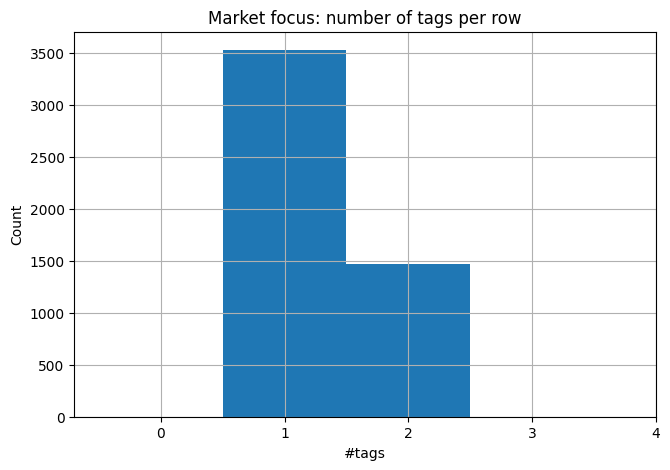

,count
market_focus,
1,3531
2,1469


In [11]:

# Market focus: distribution of number of tags
n_tags = mf.apply(len)

plt.figure()
plt.hist(n_tags, bins=np.arange(-0.5, 4.5, 1))
plt.title("Market focus: number of tags per row")
plt.xlabel("#tags")
plt.ylabel("Count")
plt.xticks([0,1,2,3,4])
plt.show()

n_tags.value_counts(dropna=False).to_frame("count")


In [12]:

# Market focus: tag frequency + percentage
tag_freq = {t: int(mf.apply(lambda lst: t in lst).sum()) for t in TAGS}
tag_pct = {t: float(mf.apply(lambda lst: t in lst).mean()) for t in TAGS}

tag_table = pd.DataFrame({
    "count": pd.Series(tag_freq),
    "pct": pd.Series(tag_pct),
}).sort_values("count", ascending=False)

tag_table


,count,pct
Industrial,2053,0.4106
Ads,1683,0.3366
Contract,1497,0.2994
Scale,1236,0.2472


In [13]:

# Market focus: invalid formatting and unknown tags
is_list_raw = df["market_focus"].apply(lambda x: isinstance(x, list))
unknown_tag = mf.apply(lambda lst: any(t not in TAGS for t in lst))

print(f"Formatting invalid rate (raw not list): {float((~is_list_raw).mean()):.3f}")
print(f"Unknown tag rate (after parsing):       {float(unknown_tag.mean()):.3f}")

# examples of suspicious rows
df.loc[unknown_tag, ["market_focus"]].head(10)


Formatting invalid rate (raw not list): 1.000
Unknown tag rate (after parsing):       0.000


,market_focus


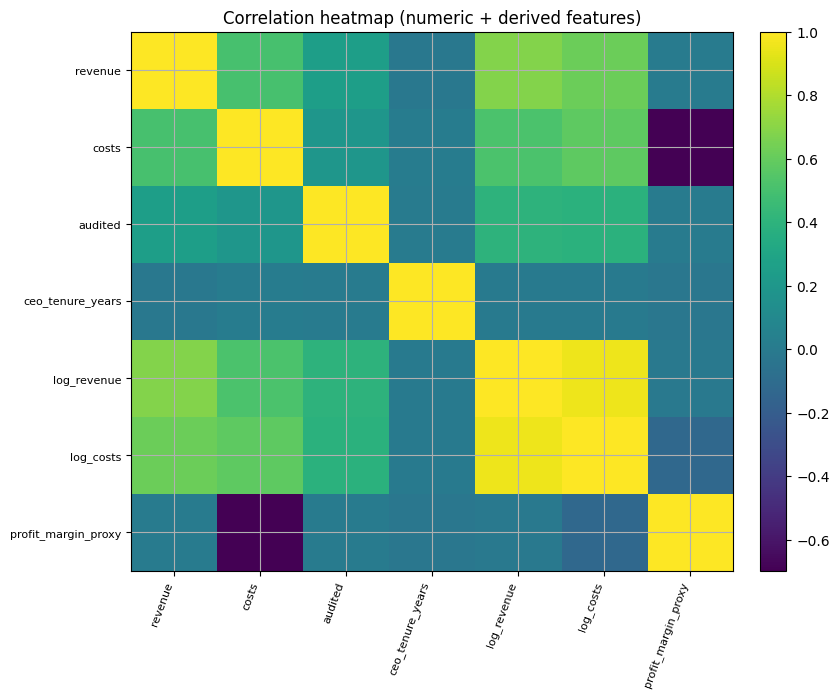

,revenue,costs,audited,ceo_tenure_years,log_revenue,log_costs,profit_margin_proxy
revenue,1.000000,0.509305,0.251204,-0.018472,0.688365,0.620140,0.008671
costs,0.509305,1.000000,0.194674,0.015569,0.521776,0.577062,-0.697382
audited,0.251204,0.194674,1.000000,0.009776,0.402911,0.383944,0.009262
ceo_tenure_years,-0.018472,0.015569,0.009776,1.000000,-0.006058,0.000163,-0.021085
log_revenue,0.688365,0.521776,0.402911,-0.006058,1.000000,0.957686,-0.010978
log_costs,0.620140,0.577062,0.383944,0.000163,0.957686,1.000000,-0.121733
profit_margin_proxy,0.008671,-0.697382,0.009262,-0.021085,-0.010978,-0.121733,1.000000


In [14]:

# Correlations between numeric features (including derived)
corr = num.corr(numeric_only=True)

plt.figure(figsize=(8.5, 7.0))
im = plt.imshow(corr.to_numpy(), aspect="auto")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=70, ha="right", fontsize=8)
plt.yticks(range(len(corr.index)), corr.index, fontsize=8)
plt.title("Correlation heatmap (numeric + derived features)")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.show()

corr


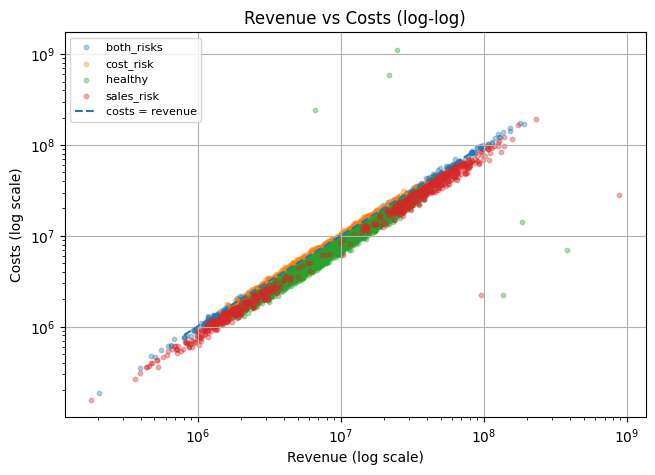

In [15]:

# Scatter: revenue vs costs (log-log) with identity line
d = df[["revenue","costs","risk"]].copy()
d["revenue"] = pd.to_numeric(d["revenue"], errors="coerce")
d["costs"] = pd.to_numeric(d["costs"], errors="coerce")
d = d.dropna()

# sample for speed
if len(d) > 8000:
    d = d.sample(8000, random_state=0)

classes = sorted(d["risk"].astype(str).unique().tolist())
plt.figure()
for cls in classes:
    sub = d[d["risk"].astype(str) == cls]
    plt.scatter(sub["revenue"], sub["costs"], s=10, alpha=0.35, label=cls)

xy = np.concatenate([d["revenue"].to_numpy(), d["costs"].to_numpy()])
lo, hi = np.nanpercentile(xy, 1), np.nanpercentile(xy, 99)
plt.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1.5, label="costs = revenue")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Revenue (log scale)")
plt.ylabel("Costs (log scale)")
plt.title("Revenue vs Costs (log-log)")
plt.legend(fontsize=8)
plt.show()


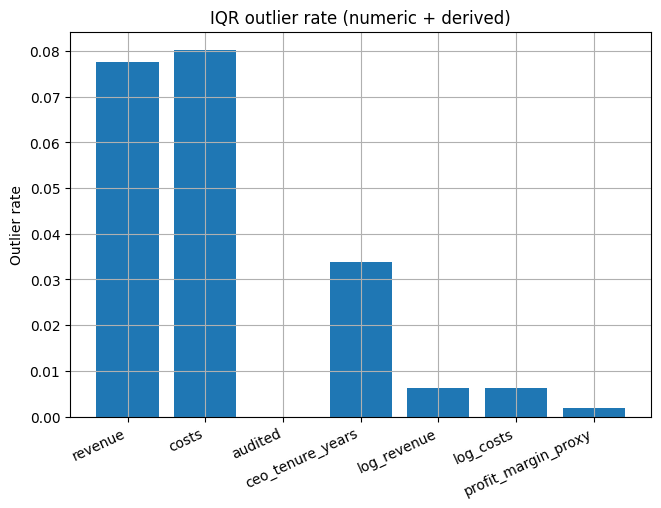

,iqr_outlier_rate,nan_rate
feature,,
revenue,0.077600,0.0000
costs,0.080200,0.0000
audited,0.000000,0.0002
ceo_tenure_years,0.033807,0.0002
log_revenue,0.006200,0.0000
log_costs,0.006200,0.0000
profit_margin_proxy,0.001800,0.0000


In [16]:

# Outlier diagnostics (IQR outlier rate + NaN rate) for numeric columns
def robust_outlier_rate(x: pd.Series):
    v = pd.to_numeric(x, errors="coerce").to_numpy()
    nan_rate = np.isnan(v).mean()
    v2 = v[~np.isnan(v)]
    if len(v2) < 10:
        return 0.0, float(nan_rate)
    q1, q3 = np.quantile(v2, [0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    out_rate = ((v2 < lo) | (v2 > hi)).mean()
    return float(out_rate), float(nan_rate)

rep = []
for col in ["revenue","costs","audited","ceo_tenure_years","log_revenue","log_costs","profit_margin_proxy"]:
    out_rate, nan_rate = robust_outlier_rate(num[col])
    rep.append({"feature": col, "iqr_outlier_rate": out_rate, "nan_rate": nan_rate})

rep = pd.DataFrame(rep).set_index("feature")

plt.figure()
plt.bar(rep.index, rep["iqr_outlier_rate"].values)
plt.title("IQR outlier rate (numeric + derived)")
plt.ylabel("Outlier rate")
plt.xticks(rotation=25, ha="right")
plt.show()

rep


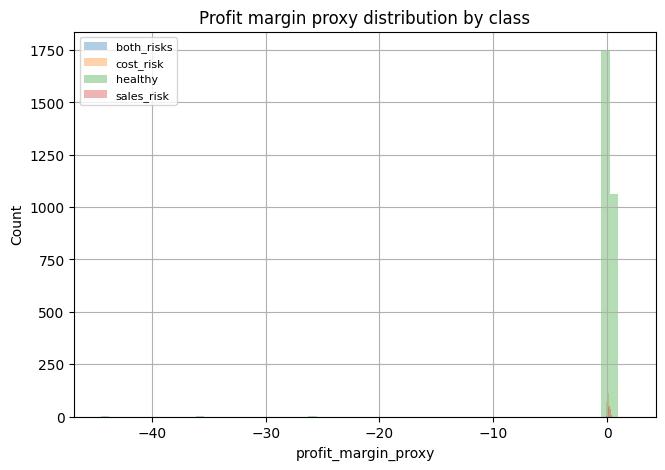

In [17]:

# Risk vs profit_margin_proxy (diagnostic separability plot)
d = num.copy()
d["risk"] = df["risk"].astype(str)
d = d.dropna(subset=["profit_margin_proxy"])

plt.figure()
for cls in sorted(d["risk"].unique()):
    sub = d[d["risk"] == cls]
    plt.hist(sub["profit_margin_proxy"], bins=60, alpha=0.35, label=cls)

plt.title("Profit margin proxy distribution by class")
plt.xlabel("profit_margin_proxy")
plt.ylabel("Count")
plt.legend(fontsize=8)
plt.show()
